Last modified : 2026.03  
작성자 : 박광석 (모두의연구소)  

# Day 5 — [프로젝트 1] 정형 데이터 예측 서비스

## 1. 프로젝트 개요: 정형 데이터 기반 예측 서비스 설계

---

> **학습 목표**
> - 프로젝트 1의 전체 구조와 최종 결과물을 파악합니다.
> - 캘리포니아 주택 가격 데이터셋을 이해합니다.
> - Day 1~4에서 배운 기술이 프로젝트에서 어떻게 조합되는지 미리 봅니다.

---

### 1.1 오늘 만들 것

Day 1~4까지 MNIST 예제로 조각들을 익혔습니다.
오늘은 **새로운 데이터, 새로운 모델**로 전체 파이프라인을 처음부터 끝까지 직접 구축합니다.

```
[최종 결과물]

브라우저에서:
  1. 주택 정보(면적, 방 수, 위치 등)를 입력합니다.
  2. "가격 예측" 버튼을 누릅니다.
  3. 예상 주택 가격이 표시됩니다.

내부 구조:
  Streamlit (입력 폼) → FastAPI (추론 API) → PyTorch 모델 (가격 예측)
```

In [1]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
# Colab의 nest_asyncio 방식 대신, macOS에서도 안정적인 표준 asyncio 루프를 사용합니다.
print("도우미 로딩 중...", flush=True)

import os, sys, asyncio, threading, time, socket, contextlib, subprocess, signal
from pathlib import Path

print("uvicorn import 중...", flush=True)
import uvicorn
print("uvicorn 준비 완료", flush=True)

# 작업 디렉터리를 DP05 루트(app/ 가 생길 위치)로 맞춥니다.
cwd = Path.cwd()
if (cwd / "DP05.ipynb").exists() or (cwd / "app").exists():
    pass
elif (cwd / "DP05" / "DP05.ipynb").exists():
    os.chdir(cwd / "DP05")
elif cwd.name == "notebooks" and (cwd.parent / "app").exists():
    os.chdir(cwd.parent)

for _d in ("app", "models", "data", "frontend"):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def _pids_on_port(port):
    """해당 포트를 LISTEN 중인 프로세스 PID 목록을 반환합니다."""
    try:
        out = subprocess.check_output(
            ["lsof", "-nP", f"-iTCP:{port}", "-sTCP:LISTEN", "-t"],
            text=True,
            stderr=subprocess.DEVNULL,
            timeout=2,
        )
    except (subprocess.CalledProcessError, FileNotFoundError, subprocess.TimeoutExpired):
        return []
    pids = []
    for line in out.split():
        try:
            pid = int(line)
        except ValueError:
            continue
        if pid != os.getpid():
            pids.append(pid)
    return pids

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다. 같은 포트의 다른 프로세스도 종료합니다."""
    entry = _SERVERS.pop(port, None)
    if entry:
        server, thread = entry
        server.should_exit = True
        for _ in range(50):
            if not thread.is_alive():
                break
            time.sleep(0.1)
    for pid in _pids_on_port(port):
        try:
            os.kill(pid, signal.SIGTERM)
        except ProcessLookupError:
            pass
    for _ in range(50):
        if not _port_open("127.0.0.1", port):
            break
        time.sleep(0.1)

def serve_in_thread(app, host="127.0.0.1", port=8000, log_level="warning"):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if isinstance(app, str):
        sys.modules.pop(app.split(":")[0], None)
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    if _port_open(host, port):
        print(f"포트 {port}가 아직 사용 중입니다. 다른 서버를 종료한 뒤 다시 실행하세요.")
        return None
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop="asyncio")
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        if sys.platform == "win32":
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    for _ in range(40):
        if getattr(server, "started", False) and _port_open(host, port):
            print(f"서버 실행됨: http://{host}:{port}")
            return server
        if not thread.is_alive():
            break
        time.sleep(0.25)
    print("서버가 시작되지 않았습니다. 위 로그를 확인하세요.")
    return server

print("서버 도우미 준비 완료 (serve_in_thread, stop_server)", flush=True)
print(f"작업 디렉터리: {Path.cwd()}", flush=True)

도우미 로딩 중...
uvicorn import 중...
uvicorn 준비 완료
서버 도우미 준비 완료 (serve_in_thread, stop_server)
작업 디렉터리: /Users/choiseunghyeon/AIFFEL_Quest_ENG/06_Deployment/DP05


---

### 1.2 데이터셋: 캘리포니아 주택 가격

scikit-learn에 내장된 `California Housing` 데이터셋을 사용합니다.
별도 다운로드가 필요 없고, 정형 데이터 예측의 대표적인 예제입니다.

In [2]:
# Colab이 아니라면 requirements.txt 설치분이 있으면 건너뜁니다.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("sklearn") is None:
    print("scikit-learn 설치 중...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
else:
    print("scikit-learn 이미 설치됨")

scikit-learn 이미 설치됨


In [3]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
print(f"샘플 수: {data.data.shape[0]:,}")
print(f"피처 수: {data.data.shape[1]}")
print(f"타겟: {data.target_names}")
print(f"\n피처 목록:")
for i, name in enumerate(data.feature_names):
    print(f"  {i+1}. {name}")

샘플 수: 20,640
피처 수: 8
타겟: ['MedHouseVal']

피처 목록:
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude


```
샘플 수: 20,640
피처 수: 8
타겟: ['MedHouseVal']

피처 목록:
  1. MedInc      — 중위 소득
  2. HouseAge    — 주택 연식
  3. AveRooms    — 평균 방 수
  4. AveBedrms   — 평균 침실 수
  5. Population  — 인구
  6. AveOccup    — 평균 거주 인원
  7. Latitude    — 위도
  8. Longitude   — 경도
```

- **입력**: 8개 피처 (숫자)
- **출력**: 중위 주택 가격 (단위: $100,000)
- **태스크**: 회귀 (Regression)

> MNIST(Day 1~4)는 이미지 분류였고, 이번 프로젝트는 **정형 데이터 회귀**입니다.
> 데이터 형태가 다르므로 전처리, 스키마, UI가 모두 달라집니다.

---

### 1.3 프로젝트 구조

```
model-serving-course/
├── 📁 app/
│   ├── model_utils.py          ← Day 1~4에서 만든 것 (MNIST용, 오늘은 건드리지 않음)
│   ├── schemas.py              ← Day 2에서 만든 것 (MNIST용, 오늘은 건드리지 않음)
│   ├── ...
│   │
│   ├── housing_model.py        ← 🆕 주택 가격 모델 정의 + 추론 함수
│   ├── housing_schemas.py      ← 🆕 주택 가격 API 스키마
│   └── housing_api.py          ← 🆕 주택 가격 FastAPI 서버
│
├── 📁 frontend/
│   ├── app_dashboard.py        ← Day 4에서 만든 것 (MNIST용)
│   └── app_housing.py          ← 🆕 주택 가격 Streamlit 대시보드
│
├── 📁 models/
│   ├── mnist_state_dict.pth    ← Day 1에서 만든 것
│   └── housing_model.pth       ← 🆕 주택 가격 모델 가중치
│
└── 📁 notebooks/
    └── day5_project1.ipynb     ← 🆕 오늘의 노트북
```

> 기존 MNIST 파일은 건드리지 않습니다.
> 프로젝트 1의 파일은 모두 `housing_` 접두사를 붙여서 구분합니다.

---

### 1.4 전체 워크플로우

```
[섹션 2] 모델 준비
    │  데이터 로드 → 전처리 → PyTorch 모델 학습 → 저장
    ▼
[섹션 3] FastAPI 백엔드
    │  Pydantic 스키마 → 추론 엔드포인트 → 비동기 처리
    ▼
[섹션 4] Streamlit 프론트엔드
    │  입력 폼 → API 호출 → 결과 시각화
    ▼
[섹션 5] 통합 테스트
    │  정상 요청 / 에러 요청 / 동시 요청 테스트
    ▼
[섹션 6] 회고
```

각 섹션에서 Day 1~4의 어떤 기술이 사용되는지:



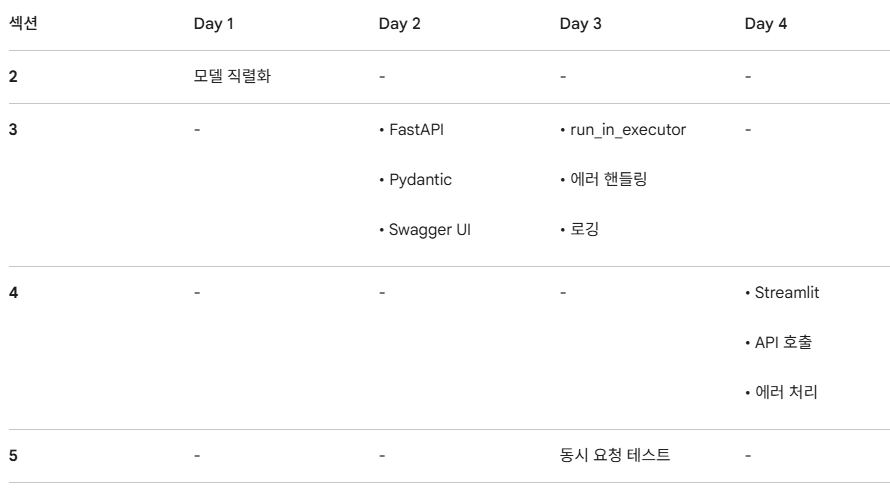

---

### 1.5 시작하기 전에

> ⚠️ **이번 프로젝트의 코드에는 `# *your code*` 주석이 포함되어 있습니다.**
>
> 지금은 전체 코드가 제공되므로 그대로 실행하시면 됩니다.
>
> `# *your code*` 옆의 코드를 직접 작성할 수 있는지 스스로 점검해 보세요.

---

### ✅ 체크포인트

1. 이 프로젝트의 입력과 출력은 각각 무엇입니까?
2. MNIST 프로젝트와 비교했을 때, 데이터 형태가 어떻게 다릅니까?
3. 오늘 새로 만들 파일 3개의 이름과 역할을 말할 수 있습니까?

---

> **다음 섹션에서는** 캘리포니아 주택 가격 데이터를 로드하고,
> PyTorch 모델을 학습하여 저장합니다.

## 2. 모델 준비: 학습 → 전처리 파이프라인 → 저장

---

> **학습 목표**
> - 캘리포니아 주택 데이터를 로드하고 탐색합니다.
> - 전처리(정규화) 파이프라인을 구성합니다.
> - PyTorch로 회귀 모델을 학습하고 저장합니다.
> - 추론 함수를 모듈로 분리합니다.

---

### 2.1 데이터 로드 및 탐색

In [4]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 데이터 로드
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"피처 크기: {X.shape}")        # (20640, 8)
print(f"타겟 크기: {y.shape}")        # (20640,)
print(f"타겟 범위: {y.min():.2f} ~ {y.max():.2f} ($100,000 단위)")
print(f"\n피처별 통계:")
for i, name in enumerate(feature_names):
    print(f"  {name:12s}  평균: {X[:, i].mean():10.2f}  표준편차: {X[:, i].std():10.2f}")

피처 크기: (20640, 8)
타겟 크기: (20640,)
타겟 범위: 0.15 ~ 5.00 ($100,000 단위)

피처별 통계:
  MedInc        평균:       3.87  표준편차:       1.90
  HouseAge      평균:      28.64  표준편차:      12.59
  AveRooms      평균:       5.43  표준편차:       2.47
  AveBedrms     평균:       1.10  표준편차:       0.47
  Population    평균:    1425.48  표준편차:    1132.43
  AveOccup      평균:       3.07  표준편차:      10.39
  Latitude      평균:      35.63  표준편차:       2.14
  Longitude     평균:    -119.57  표준편차:       2.00


In [5]:
# 학습/테스트 분할
# sklearn.train_test_split: 한 배열을 학습용(train)과 평가용(test)으로 나눕니다.
# - 테스트 셋은 학습에 쓰지 않아야 "본 적 없는 데이터"로 일반화 성능을 볼 수 있습니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    # *your code* — test_size와 random_state 설정
    test_size=0.2,      # 전체 샘플의 20%를 테스트, 나머지 80%를 학습에 사용
    random_state=42,    # 난수 시드 고정 → 노트북을 다시 실행해도 같은 분할이 재현됨
)

print(f"학습 데이터: {X_train.shape[0]:,}개")
print(f"테스트 데이터: {X_test.shape[0]:,}개")

학습 데이터: 16,512개
테스트 데이터: 4,128개


---

### 2.2 전처리: 정규화

피처마다 값의 범위가 크게 다릅니다 (소득: 0~15, 인구: 0~35,000).
모델 학습이 안정적으로 수렴하려면 **정규화(Normalization)**가 필요합니다.

In [6]:
# 학습 데이터의 평균/표준편차 계산 (테스트 데이터에는 학습 데이터의 통계를 사용)
# X_train shape = (샘플 수 N, 피처 수 8)
# axis=0  → 샘플 축을 따라 평균/표준편차를 내므로 결과는 피처별 8개 값 (shape: (8,))
# axis를 빼면 전체 숫자를 한 값으로 뭉개 버려서, 피처마다 스케일이 다른 문제를 못 고칩니다.
# 테스트 셋의 평균/표준편차를 따로 구하면 안 됩니다. 그건 테스트 정보를 학습 파이프라인에
# 흘려 넣는 데이터 누수(data leakage)입니다. 배포 때도 이 train_mean/train_std만 사용합니다.
train_mean = X_train.mean(axis=0)  # *your code* — 축(axis) 설정: 행(샘플) 방향 → 피처별 평균
train_std = X_train.std(axis=0)    # *your code* — 축(axis) 설정: 행(샘플) 방향 → 피처별 표준편차

print("피처별 평균:", np.round(train_mean, 2))
print("피처별 표준편차:", np.round(train_std, 2))

피처별 평균: [ 3.88000e+00  2.86100e+01  5.44000e+00  1.10000e+00  1.42645e+03
  3.10000e+00  3.56400e+01 -1.19580e+02]
피처별 표준편차: [1.90000e+00 1.26000e+01 2.39000e+00 4.30000e-01 1.13702e+03 1.15800e+01
 2.14000e+00 2.01000e+00]


In [7]:
# 정규화 적용
# 표준화(z-score): 각 피처를 (값 - 평균) / 표준편차 로 바꿔 평균≈0, 표준편차≈1로 맞춥니다.
# 소득(MedInc)과 인구(Population)처럼 단위·크기가 다른 피처를 같은 스케일로 넣어야
# 신경망이 큰 숫자 피처만 편애하지 않습니다.
# 브로드캐스팅: (N, 8) - (8,) → 각 행에서 같은 피처의 평균/표준편차를 빼고 나눕니다.
X_train_norm = (X_train - train_mean) / train_std  # *your code* — 정규화 공식
X_test_norm = (X_test - train_mean) / train_std     # 테스트에도 학습 데이터의 통계 사용 (누수 방지)

print(f"정규화 후 학습 데이터 평균: {X_train_norm.mean(axis=0).round(4)}")  # 거의 0
print(f"정규화 후 학습 데이터 표준편차: {X_train_norm.std(axis=0).round(4)}")  # 거의 1

정규화 후 학습 데이터 평균: [-0. -0.  0. -0. -0. -0.  0. -0.]
정규화 후 학습 데이터 표준편차: [1. 1. 1. 1. 1. 1. 1. 1.]


> ⚠️ **왜 학습 데이터의 통계로 테스트 데이터를 정규화합니까?**
>
> 테스트 데이터는 "실제 배포 환경에서 들어올 새로운 데이터"를 시뮬레이션합니다.
> 새로운 데이터의 통계를 미리 알 수 없으므로, 학습 데이터의 통계를 사용합니다.
> 이 평균/표준편차 값은 배포 시에도 함께 저장해야 합니다.

In [8]:
# 텐서 변환
# PyTorch 모델은 numpy 배열이 아니라 torch.Tensor를 받습니다. FloatTensor = 32bit 실수.
X_train_tensor = torch.FloatTensor(X_train_norm)
# y_train은 원래 1차원 (N,) 입니다. 모델 출력은 Linear(..., 1)이라 (N, 1) 입니다.
# MSELoss는 두 텐서의 shape가 같아야 하므로, unsqueeze(1)로 마지막에 축 1개를 붙입니다.
#   (16512,) → (16512, 1)   ↔  "열 벡터"로 만들어 예측값과 원소별 뺄셈이 되게 함
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)  # *your code* — (N,) → (N,1)
X_test_tensor = torch.FloatTensor(X_test_norm)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

print(f"X_train 텐서: {X_train_tensor.shape}")  # torch.Size([16512, 8])
print(f"y_train 텐서: {y_train_tensor.shape}")  # torch.Size([16512, 1])

X_train 텐서: torch.Size([16512, 8])
y_train 텐서: torch.Size([16512, 1])


---

### 2.3 모델 정의 및 학습

In [9]:
class HousingModel(nn.Module):
    """캘리포니아 주택 가격 예측 모델 (회귀)"""
    def __init__(self, input_dim=8):
        super().__init__()
        # Sequential: 아래 층을 앞에서 뒤로 순서대로 통과시킵니다.
        self.network = nn.Sequential(
            # *your code* — 입력 차원 → 64
            # Linear(in, out): y = xW^T + b. 입력 8개 피처를 64차원 은닉 표현으로 확장
            nn.Linear(input_dim, 64),
            nn.ReLU(),          # 비선형 활성화. 없으면 층을 쌓아도 한 번의 선형 변환과 같음
            nn.Dropout(0.2),    # 학습 중 뉴런 20%를 무작위로 꺼서 과적합을 완화
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            # *your code* — 32 → 1 (회귀 출력)
            # MNIST 분류는 클래스 수(10)만큼 출력이 필요했지만,
            # 가격 예측(회귀)은 "한 개의 실수"만 필요하므로 out_features=1
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

model = HousingModel(input_dim=8)
print(f"모델 구조:\n{model}")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

모델 구조:
HousingModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
파라미터 수: 2,689


In [10]:
# 학습 설정
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# *your code* — 회귀이므로 MSELoss
# MSE(Mean Squared Error) = 평균(예측 - 정답)²
# 가격처럼 연속 값을 맞출 때 사용. MNIST처럼 클래스 번호를 맞출 때는 CrossEntropyLoss.
criterion = nn.MSELoss()
# *your code* — Adam 옵티마이저 (lr=1e-3)
# model.parameters()로 모든 가중치/편향을 넘겨, loss.backward()로 쌓인 기울기로 갱신합니다.
# lr=1e-3(0.001)은 Adam의 흔한 시작 학습률입니다.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 50

In [11]:
# 학습 루프
model.train()
for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()  # 이전 배치의 기울기가 남아 있으면 누적되므로 먼저 0으로 초기화
        # *your code* — 순전파(forward): 입력 배치가 Sequential 층을 지나 (batch, 1) 예측이 나옴
        predictions = model(X_batch)
        # *your code* — 손실 계산: 예측과 정답 y_batch의 MSE. 이 스칼라를 줄이는 것이 학습 목표
        loss = criterion(predictions, y_batch)
        loss.backward()   # 역전파: 각 파라미터에 대해 "loss를 얼마나 줄이는 방향인지" 기울기 계산
        optimizer.step()  # Adam이 기울기를 보고 가중치를 한 스텝 업데이트
        running_loss += loss.item()

    if epoch % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch:3d}/{EPOCHS} — Loss: {avg_loss:.4f}")

Epoch  10/50 — Loss: 0.5661
Epoch  20/50 — Loss: 0.4831
Epoch  30/50 — Loss: 0.4392
Epoch  40/50 — Loss: 0.4106
Epoch  50/50 — Loss: 0.3894


In [12]:
# 테스트 평가
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor)
    test_loss = criterion(test_preds, y_test_tensor)

    # MAE (Mean Absolute Error) 계산
    mae = torch.abs(test_preds - y_test_tensor).mean().item()

print(f"테스트 MSE:  {test_loss.item():.4f}")
print(f"테스트 MAE:  {mae:.4f} ($100,000 단위)")
print(f"테스트 MAE:  ${mae * 100000:,.0f} (실제 금액)")

테스트 MSE:  0.3219
테스트 MAE:  0.3867 ($100,000 단위)
테스트 MAE:  $38,666 (실제 금액)


---

### 2.4 모델 및 전처리 파라미터 저장

In [13]:
import os
os.makedirs("models", exist_ok=True)

# 모델 가중치 저장
# state_dict()는 "층 이름 → 텐서" 딕셔너리만 담습니다 (구조 클래스 코드는 포함하지 않음).
# 배포 시 HousingModel()을 같은 구조로 만든 뒤 load_state_dict()로 이 파일만 얹으면 됩니다.
# model 객체 전체를 pickle 저장하면 클래스 정의가 바뀌었을 때 로드가 깨지기 쉬워, 가중치만 저장합니다.
torch.save(model.state_dict(), "models/housing_model.pth")  # *your code* — state_dict 저장
print(f"✅ 모델 저장: models/housing_model.pth ({os.path.getsize('models/housing_model.pth')/1024:.1f} KB)")

# 전처리 파라미터 저장 (배포 시 필수!)
preprocessing_params = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "feature_names": feature_names,
}

import json
with open("models/housing_preprocessing.json", "w") as f:
    json.dump(preprocessing_params, f, indent=2)

print(f"✅ 전처리 파라미터 저장: models/housing_preprocessing.json")

✅ 모델 저장: models/housing_model.pth (13.3 KB)
✅ 전처리 파라미터 저장: models/housing_preprocessing.json


> ⚠️ **전처리 파라미터를 반드시 함께 저장해야 합니다.**
>
> 모델만 저장하고 `train_mean`, `train_std`를 저장하지 않으면,
> 배포 환경에서 정규화를 할 수 없어 잘못된 예측이 나옵니다.
> Day 1에서 ".pth 파일만 전달하면 안 된다"고 배운 것과 같은 맥락입니다.

---

### 2.5 추론 모듈 작성

Day 1에서 `app/model_utils.py`를 만든 것과 동일한 패턴입니다.

In [14]:
%%writefile app/housing_model.py
"""
Day 5 - 주택 가격 예측 모델 정의 + 추론 함수
"""
import json
import torch
import torch.nn as nn
import numpy as np


class HousingModel(nn.Module):
    """캘리포니아 주택 가격 예측 모델"""
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


class HousingPredictor:
    """모델 로드 + 전처리 + 추론을 캡슐화한 클래스"""

    def __init__(self, model_path: str, preprocessing_path: str):
        # 전처리 파라미터 로드
        with open(preprocessing_path, "r") as f:
            params = json.load(f)
        self.mean = np.array(params["mean"])
        self.std = np.array(params["std"])
        self.feature_names = params["feature_names"]

        # 모델 로드
        self.model = HousingModel(input_dim=len(self.feature_names))
        self.model.load_state_dict(
            torch.load(model_path, map_location="cpu", weights_only=True)
        )
        self.model.eval()

    def predict(self, features: dict) -> dict:
        """
        피처 딕셔너리를 받아 가격을 예측합니다.

        Args:
            features: {"MedInc": 3.5, "HouseAge": 25, ...}
        Returns:
            {"predicted_price": 2.35, "predicted_price_usd": 235000}
        """
        # 피처를 올바른 순서로 배열
        # API/Streamlit은 dict로 값을 보내므로 키 순서가 뒤섞일 수 있습니다.
        # 학습 때 쓴 feature_names 순서(MedInc, HouseAge, ... Longitude)로 리스트를 만들어야
        # 정규화 벡터 self.mean/self.std의 i번째 값과 같은 피처가 짝을 맞습니다.
        values = [features[name] for name in self.feature_names]  # *your code* — 피처 순서 맞추기

        # 정규화
        values = np.array(values, dtype=np.float32)
        # 학습과 동일한 z-score. 배포 서버가 학습 통계(housing_preprocessing.json)를
        # 쓰는 이유: 추론 입력을 학습 때와 같은 스케일로 맞춰야 모델이 의미를 알아봅니다.
        normalized = (values - self.mean) / self.std              # *your code* — 정규화 적용

        # 추론
        input_tensor = torch.FloatTensor(normalized).unsqueeze(0)  # (1, 8)
        with torch.no_grad():
            output = self.model(input_tensor)

        price = output.item()
        price = max(price, 0.0)  # 음수 방지

        return {
            "predicted_price": round(price, 4),
            "predicted_price_usd": int(price * 100000),
        }

Overwriting app/housing_model.py


In [15]:
# 모듈 테스트
import sys
sys.path.insert(0, ".")

from app.housing_model import HousingPredictor

predictor = HousingPredictor(
    model_path="models/housing_model.pth",
    preprocessing_path="models/housing_preprocessing.json",
)

# 테스트 데이터의 첫 번째 샘플로 테스트
sample_features = {name: float(X_test[0, i]) for i, name in enumerate(feature_names)}
print(f"입력 피처: {sample_features}")

result = predictor.predict(sample_features)
print(f"예측 가격: ${result['predicted_price_usd']:,}")
print(f"실제 가격: ${int(y_test[0] * 100000):,}")

입력 피처: {'MedInc': 1.6812, 'HouseAge': 25.0, 'AveRooms': 4.192200557103064, 'AveBedrms': 1.0222841225626742, 'Population': 1392.0, 'AveOccup': 3.8774373259052926, 'Latitude': 36.06, 'Longitude': -119.01}
예측 가격: $67,121
실제 가격: $47,700


---

### ✅ 체크포인트

1. 정규화에서 학습 데이터의 통계를 테스트 데이터에도 사용하는 이유는 무엇입니까?
2. 모델 가중치 외에 **함께 저장해야 하는 것**은 무엇이고, 왜 필요합니까?
3. `HousingPredictor.predict()`에서 피처를 `self.feature_names` 순서로 배열하는 이유는?

---

> **다음 섹션에서는** 이 `HousingPredictor`를 FastAPI 엔드포인트에 연결합니다.

## 3. FastAPI 백엔드: 추론 엔드포인트 + Pydantic 스키마

---

> **학습 목표**
> - 주택 가격 예측용 Pydantic 스키마를 설계합니다.
> - FastAPI 엔드포인트를 구현하고 비동기 처리를 적용합니다.
> - Swagger UI에서 API를 테스트합니다.

---

### 3.1 Pydantic 스키마 설계

In [16]:
%%writefile app/housing_schemas.py
"""
Day 5 - 주택 가격 예측 API 스키마
"""
from pydantic import BaseModel, Field


class HousingRequest(BaseModel):
    """주택 가격 예측 요청"""
    # Field(...): 필수 필드. 값이 없으면 422 Unprocessable Entity.
    # gt=0 (greater than): 중위 소득은 0보다 커야 함. 0·음수는 스키마 단계에서 거절.
    MedInc: float = Field(..., gt=0, description="중위 소득")                        # *your code* — gt=0 설정
    # ge=0, le=100: 0년 이상 100년 이하. 데이터셋 HouseAge 상한이 약 52여도
    # 실무 입력은 여유 있게 100까지 허용하는 경우가 많습니다.
    HouseAge: float = Field(..., ge=0, le=100, description="주택 연식 (년)")          # *your code* — ge, le 범위
    AveRooms: float = Field(..., gt=0, description="평균 방 수")
    AveBedrms: float = Field(..., gt=0, description="평균 침실 수")
    Population: float = Field(..., gt=0, description="인구")
    AveOccup: float = Field(..., gt=0, description="평균 거주 인원")
    # 이 모델은 캘리포니아 주택 데이터로만 학습됨. 위도를 32~42로 막아
    # 학습 분포 밖의 좌표가 들어와 지리 피처가 의미 없게 쓰이지 않게 합니다.
    Latitude: float = Field(..., ge=32, le=42, description="위도 (캘리포니아 범위)")   # *your code* — 캘리포니아 위도 범위
    Longitude: float = Field(..., ge=-125, le=-114, description="경도 (캘리포니아 범위)")

    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "MedInc": 3.5,
                    "HouseAge": 25.0,
                    "AveRooms": 5.0,
                    "AveBedrms": 1.0,
                    "Population": 1500.0,
                    "AveOccup": 3.0,
                    "Latitude": 37.5,
                    "Longitude": -122.0,
                }
            ]
        }
    }


class HousingResponse(BaseModel):
    """주택 가격 예측 응답"""
    success: bool = Field(description="요청 처리 성공 여부")
    predicted_price: float = Field(description="예측 가격 ($100,000 단위)")
    predicted_price_usd: int = Field(description="예측 가격 (USD)")
    input_features: dict = Field(description="입력된 피처 값")


Overwriting app/housing_schemas.py


> Day 2에서 배운 `Field()`를 그대로 활용합니다.
> 캘리포니아 데이터이므로 위도/경도에 범위 제한을 넣어 잘못된 입력을 방지합니다.

---

### 3.2 FastAPI 서버 구현

> ⚠️ **Day 5부터 바로 시작했거나, Colab 세션이 새로 떴거나 로컬에서 DP05만 연 경우**
>
> 아래에서 만들 `housing_api.py`는 Day 3에서 만든 로깅/에러 처리 파일
> (`logger_config.py`, `error_handlers.py`, `middleware.py`)을 import 합니다.
> 아래 셀을 실행하면 없는 파일만 자동으로 만들어 줍니다. (이미 있으면 그대로 둡니다)

In [17]:
# Day 3에서 만든 로깅/에러 처리 파일을 확인하고, 없으면 새로 만듭니다.
# (아래에서 만들 housing_api.py 가 이 파일들을 import 합니다)
import os

os.makedirs("app", exist_ok=True)

BACKEND_FILES = {}

BACKEND_FILES["app/logger_config.py"] = r'''"""
Day 3 - 로깅 설정
"""
import logging
import sys


def setup_logger(name: str = "ml_api", level: str = "INFO") -> logging.Logger:
    """콘솔 로거를 설정합니다."""
    logger = logging.getLogger(name)
    logger.setLevel(getattr(logging, level))

    if logger.handlers:
        return logger

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.DEBUG)

    formatter = logging.Formatter(
        fmt="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    return logger'''

BACKEND_FILES["app/error_handlers.py"] = r'''"""
Day 3 - 글로벌 에러 핸들러
"""
import traceback
import logging

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

logger = logging.getLogger("ml_api")


def register_error_handlers(app: FastAPI):
    """FastAPI 앱에 글로벌 에러 핸들러를 등록합니다."""

    @app.exception_handler(Exception)
    async def general_error_handler(request: Request, exc: Exception):
        """모든 예외를 잡아서 안전한 응답을 반환합니다."""
        logger.error(
            f"에러 발생: {type(exc).__name__}: {exc}\n"
            f"경로: {request.method} {request.url}\n"
            f"스택 트레이스:\n{traceback.format_exc()}"
        )
        return JSONResponse(
            status_code=500,
            content={
                "success": False,
                "error": "서버 내부 오류가 발생했습니다.",
            }
            # ⚠️ 클라이언트에게는 상세 정보를 노출하지 않습니다.
            # 상세 정보는 서버 로그에만 기록됩니다.
        )'''

BACKEND_FILES["app/middleware.py"] = r'''"""
Day 3 - 요청/응답 로깅 미들웨어
모든 요청의 메서드, 경로, 응답 시간, 상태 코드를 자동 로깅합니다.
"""
import time
import logging
from fastapi import Request
from starlette.middleware.base import BaseHTTPMiddleware

logger = logging.getLogger("ml_api")


class RequestLoggingMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request: Request, call_next):
        start_time = time.time()
        response = await call_next(request)
        duration = round(time.time() - start_time, 3)

        log_message = (
            f"{request.method} {request.url.path} "
            f"→ {response.status_code} "
            f"({duration}s)"
        )

        if response.status_code >= 500:
            logger.error(log_message)
        elif response.status_code >= 400:
            logger.warning(log_message)
        else:
            logger.info(log_message)

        response.headers["X-Process-Time"] = str(duration)
        return response'''

for _path, _body in BACKEND_FILES.items():
    if os.path.exists(_path):
        print(f"✅ {_path} 있음")
    else:
        print(f"⚠️ {_path} 없음 → 생성합니다.")
        with open(_path, "w", encoding="utf-8") as f:
            f.write(_body)

print("\n🎉 준비 완료. 다음 셀로 진행하세요.")


✅ app/logger_config.py 있음
✅ app/error_handlers.py 있음
✅ app/middleware.py 있음

🎉 준비 완료. 다음 셀로 진행하세요.


In [18]:
%%writefile app/housing_api.py
"""
Day 5 - 주택 가격 예측 FastAPI 서버
"""
import asyncio
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, HTTPException

from app.housing_schemas import HousingRequest, HousingResponse
from app.housing_model import HousingPredictor
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# ===== 설정 =====
logger = setup_logger("housing_api")

app = FastAPI(
    title="California Housing Price API",
    description="캘리포니아 주택 가격을 예측하는 API",
    version="1.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

# 추론 전용 스레드풀 (Day 3에서 배운 패턴)
# PyTorch 추론은 CPU를 오래 쓰는 동기 작업이라, async def 안에서 그대로 호출하면
# 이벤트 루프가 멈춰 다른 /health 요청까지 지연됩니다.
# ThreadPoolExecutor에 넘기면 루프는 비워 두고, 스레드에서 predict()만 실행합니다.
# max_workers=4: 동시에 최대 4개 추론. thread_name_prefix는 로그에서 스레드를 구분할 때 사용.
inference_executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="housing")  # *your code* — 스레드풀 생성

# ===== 모델 로드 =====
MODEL_PATH = "models/housing_model.pth"
PREPROCESS_PATH = "models/housing_preprocessing.json"
predictor = None


@app.on_event("startup")
async def startup():
    global predictor
    logger.info("주택 가격 모델 로드 중...")
    # 서버가 뜨는 시점에 모델·전처리 JSON을 한 번만 로드합니다.
    # 요청마다 torch.load 하면 수백 ms~수 초가 반복되므로, 전역 predictor를 재사용합니다.
    predictor = HousingPredictor(MODEL_PATH, PREPROCESS_PATH)  # *your code* — HousingPredictor 인스턴스 생성
    logger.info("모델 로드 완료")


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if predictor is not None else "loading",
        "model": "California Housing",
    }


@app.post("/predict", response_model=HousingResponse, tags=["Prediction"])
async def predict_housing(request: HousingRequest):
    """주택 정보를 받아 가격을 예측합니다."""
    if predictor is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    # Pydantic 모델을 dict로 변환 (키 이름은 스키마 필드와 동일: MedInc, HouseAge, ...)
    # HousingPredictor.predict()는 dict를 받으므로 model_dump()가 다리 역할을 합니다.
    features = request.model_dump()  # *your code* — Pydantic 모델 → dict

    try:
        # 추론 (별도 스레드에서 실행 — Day 3 패턴)
        loop = asyncio.get_running_loop()
        # run_in_executor(executor, func, *args): func(*args)를 스레드풀에서 실행하고,
        # 끝날 때까지 await로 기다립니다. 그동안 이벤트 루프는 다른 요청을 받을 수 있습니다.
        result = await loop.run_in_executor(       # *your code* — run_in_executor 사용
            inference_executor,              # 추론 전용 스레드풀
            predictor.predict,              # 실행할 동기 함수
            features,              # 함수에 전달할 인자
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    return HousingResponse(
        success=True,
        predicted_price=result["predicted_price"],
        predicted_price_usd=result["predicted_price_usd"],
        input_features=features,
    )


Overwriting app/housing_api.py


---

### 3.3 서버 실행 및 Swagger 테스트

In [19]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
# 이 셀이 "서버 실행됨"을 출력한 뒤에만 /health, /docs 를 호출하세요.
server = serve_in_thread("app.housing_api:app", port=8000)
if server is None:
    print("서버가 뜨지 않았습니다. 위 도우미 셀을 다시 실행한 뒤, 이 셀을 재실행하세요.")

2026-08-19 12:39:27 INFO     [housing_api] 주택 가격 모델 로드 중...
2026-08-19 12:39:27 INFO     [housing_api] 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


서버가 떴으니 Swagger UI로 API를 확인합니다.  

- 로컬: 브라우저에서 http://localhost:8000/docs 를 여세요.
- Colab: localhost 접속이 안 되므로, 아래 셀이 노트북 안에 Swagger UI를 띄워 줍니다.


In [20]:
# Swagger UI 열기 — Colab은 iframe, 로컬(Mac)은 브라우저 탭
import socket, contextlib

try:
    from google.colab import output as _colab_output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DOCS_URL = "http://localhost:8000/docs"

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

if not _port_open("127.0.0.1", 8000):
    print("❌ 포트 8000에 서버가 없습니다. 바로 위 `serve_in_thread` 셀을 먼저 실행하세요.")
else:
    if IN_COLAB:
        from google.colab import output
        print("✅ Swagger UI를 아래에 띄웁니다 (Colab 프록시 → 포트 8000)")
        output.serve_kernel_port_as_iframe(8000, path="/docs", height="700")
    else:
        import webbrowser
        print(f"✅ 브라우저에서 엽니다: {DOCS_URL}")
        print("   (Jupyter iframe은 localhost X-Frame 제한으로 비어 보일 수 있습니다)")
        webbrowser.open(DOCS_URL)

✅ 브라우저에서 엽니다: http://localhost:8000/docs
   (Jupyter iframe은 localhost X-Frame 제한으로 비어 보일 수 있습니다)


In [21]:
import requests, json

# 헬스체크 — FastAPI 서버가 8000에서 떠 있어야 합니다.
try:
    resp = requests.get("http://localhost:8000/health", timeout=3)
    print(f"헬스체크: {resp.json()}")
except requests.exceptions.ConnectionError:
    print("❌ Connection refused: http://localhost:8000 에 서버가 없습니다.")
    print("   섹션 3.3의 serve_in_thread(\"app.housing_api:app\", port=8000) 셀을 먼저 실행하세요.")
    print("   커널은 DP05 .venv 를 사용하세요. (Select Kernel → Jupyter Kernel → DP05 .venv)")

헬스체크: {'status': 'healthy', 'model': 'California Housing'}


In [22]:
# 추론 테스트
sample_request = {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 5.0,
    "AveBedrms": 1.0,
    "Population": 1500.0,
    "AveOccup": 3.0,
    "Latitude": 37.5,
    "Longitude": -122.0,
}

resp = requests.post("http://localhost:8000/predict", json=sample_request)
result = resp.json()

print(f"상태 코드: {resp.status_code}")
print(f"예측 가격: ${result['predicted_price_usd']:,}")
print(f"전체 응답:")
print(json.dumps(result, indent=2, ensure_ascii=False))

상태 코드: 200
예측 가격: $180,799
전체 응답:
{
  "success": true,
  "predicted_price": 1.808,
  "predicted_price_usd": 180799,
  "input_features": {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 5.0,
    "AveBedrms": 1.0,
    "Population": 1500.0,
    "AveOccup": 3.0,
    "Latitude": 37.5,
    "Longitude": -122.0
  }
}


In [23]:
# 에러 테스트: 필수 필드 누락
resp = requests.post("http://localhost:8000/predict", json={"MedInc": 3.5})
print(f"필드 누락 → 상태: {resp.status_code}")

# 에러 테스트: 범위 초과
resp = requests.post("http://localhost:8000/predict", json={
    **sample_request, "Latitude": 50.0  # 캘리포니아 범위 초과
})
print(f"범위 초과 → 상태: {resp.status_code}")

POST /predict → 422 (0.001s)
POST /predict → 422 (0.001s)


필드 누락 → 상태: 422
범위 초과 → 상태: 422


---

### ✅ 체크포인트

1. `HousingRequest`에서 `Latitude`에 `ge=32, le=42` 제한을 넣은 이유는?
2. `request.model_dump()`는 어떤 역할을 합니까?
3. `run_in_executor`를 사용하지 않으면 어떤 문제가 발생할 수 있습니까?

---

> **다음 섹션에서는** Streamlit 프론트엔드를 만들어 이 API와 연결합니다.


## 4. Streamlit 프론트엔드: 입력 폼 → API 호출 → 결과 시각화

---

> **학습 목표**
> - 정형 데이터 입력 폼을 Streamlit으로 구현합니다.
> - Day 4에서 배운 패턴으로 FastAPI를 호출합니다.
> - 예측 결과를 시각적으로 표시합니다.

---

### 4.1 대시보드 코드 작성

In [24]:
%%writefile frontend/app_housing.py
"""
Day 5 - 캘리포니아 주택 가격 예측 대시보드
"""
import streamlit as st
import requests

# ===== 페이지 설정 =====
st.set_page_config(
    page_title="주택 가격 예측",
    page_icon="🏠",
    layout="wide",
)

# ===== API 호출 함수 (Day 4 패턴) =====
API_BASE = "http://localhost:8000"

def call_api(url, json_data=None, method="post"):
    try:
        if method == "get":
            resp = requests.get(url, timeout=10)
        else:
            resp = requests.post(url, json=json_data, timeout=30)
        # 2xx가 아니면 HTTPError를 던집니다. 아래 except에서 사용자에게 안내합니다.
        # 이 줄이 없으면 404/500이어도 resp.json()을 시도해 앱이 깨질 수 있습니다.
        resp.raise_for_status()                      # *your code* — HTTP 에러 시 예외 발생
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.** FastAPI 서버를 실행하세요.")
        return None
    except requests.exceptions.HTTPError as e:
        st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None


# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")

    health = call_api(f"{API_BASE}/health", method="get")
    if health and health.get("status") == "healthy":
        st.success("🟢 서버 연결됨")
        server_ok = True
    else:
        st.error("🔴 서버 연결 실패")
        server_ok = False

    st.divider()
    st.caption("California Housing Price Predictor")
    st.caption("Day 5 — 프로젝트 1")


# ===== 메인 영역 =====
st.title("🏠 캘리포니아 주택 가격 예측")
st.write("주택 정보를 입력하면 예상 가격을 예측합니다.")

col_input, col_result = st.columns(2)

# ----- 입력 영역 -----
with col_input:
    st.subheader("📋 주택 정보 입력")

    # 소득 & 주택 연식
    c1, c2 = st.columns(2)
    with c1:
        med_inc = st.number_input(
            "중위 소득 (MedInc)",
            # *your code* — 범위와 기본값
            # min/max는 Pydantic gt=0 및 데이터 분포를 위젯에서 한 번 더 막습니다.
            # value=3.5는 폼을 처음 열었을 때 채워지는 기본값(대략 데이터셋 중위권).
            min_value=0.1, max_value=20.0, value=3.5, step=0.1,
        )
    with c2:
        house_age = st.number_input(
            "주택 연식 (HouseAge)",
            min_value=0.0, max_value=100.0, value=25.0, step=1.0,
        )

    # 방 수 & 침실 수
    c1, c2 = st.columns(2)
    with c1:
        ave_rooms = st.number_input(
            "평균 방 수 (AveRooms)",
            min_value=0.1, max_value=50.0, value=5.0, step=0.1,
        )
    with c2:
        ave_bedrms = st.number_input(
            "평균 침실 수 (AveBedrms)",
            min_value=0.1, max_value=20.0, value=1.0, step=0.1,
        )

    # 인구 & 거주 인원
    c1, c2 = st.columns(2)
    with c1:
        population = st.number_input(
            "인구 (Population)",
            min_value=1.0, max_value=50000.0, value=1500.0, step=100.0,
        )
    with c2:
        ave_occup = st.number_input(
            "평균 거주 인원 (AveOccup)",
            min_value=0.1, max_value=20.0, value=3.0, step=0.1,
        )

    # 위치
    c1, c2 = st.columns(2)
    with c1:
        latitude = st.number_input(
            "위도 (Latitude)",
            # *your code* — 캘리포니아 범위
            # housing_schemas.Latitude(ge=32, le=42)와 맞춰 UI에서도 막습니다.
            # 위젯 범위를 더 넓히면 API가 422를 주고, 사용자는 "서버 에러"만 보게 됩니다.
            min_value=32.0, max_value=42.0, value=37.5, step=0.1,
        )
    with c2:
        longitude = st.number_input(
            "경도 (Longitude)",
            min_value=-125.0, max_value=-114.0, value=-122.0, step=0.1,
        )


# ----- 결과 영역 -----
with col_result:
    st.subheader("📊 예측 결과")

    if not server_ok:
        st.error("서버에 연결할 수 없습니다.")
    else:
        if st.button("🚀 가격 예측", type="primary", use_container_width=True):
            # *your code* — 입력값을 dict로 구성
            # 키 이름은 HousingRequest 필드와 반드시 같아야 JSON이 스키마 검증을 통과합니다.
            # Streamlit 위젯 변수(med_inc 등)를 API가 기대하는 영문 피처명에 매핑합니다.
            request_data = {
                "MedInc": med_inc,
                "HouseAge": house_age,
                "AveRooms": ave_rooms,
                "AveBedrms": ave_bedrms,
                "Population": population,
                "AveOccup": ave_occup,
                "Latitude": latitude,
                "Longitude": longitude,
            }

            with st.spinner("예측 중..."):
                result = call_api(f"{API_BASE}/predict", json_data=request_data)

            if result:
                st.session_state["last_housing_result"] = result

        # 결과 표시
        if "last_housing_result" in st.session_state:
            result = st.session_state["last_housing_result"]

            # 가격 메트릭
            st.metric(
                label="예상 주택 가격",
                value=f"${result['predicted_price_usd']:,}",
            )

            st.caption(f"모델 출력값: {result['predicted_price']} ($100,000 단위)")

            # 입력 피처 확인
            with st.expander("📋 입력된 피처 확인"):
                for key, value in result["input_features"].items():
                    st.write(f"**{key}**: {value}")


Writing frontend/app_housing.py


---

### 4.2 실행 및 테스트

아래는 터미널에서 실행하는 명령입니다. 노트북 셀에서 직접 실행하면 셀이 끝나지 않으니, 바로 아래의 백그라운드 실행 셀을 사용하세요.

```bash
# 터미널 1: 백엔드
uvicorn app.housing_api:app --port 8000

# 터미널 2: 프론트엔드
streamlit run frontend/app_housing.py --server.port 8501
```


In [25]:
# Streamlit은 .venv에 설치되어 있으면 pip를 건너뜁니다.
import importlib.util
import sys
import subprocess
import time
import socket
import contextlib
import tempfile
import os
import webbrowser

try:
    from google.colab import output as _colab_output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if importlib.util.find_spec("streamlit") is None:
    print("Streamlit 미설치 → 지금 설치합니다.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "streamlit"])
else:
    print("Streamlit 이미 설치됨")

def run_streamlit(script, port=8501):
    """Streamlit을 백그라운드로 띄우고 포트가 열릴 때까지 확인합니다."""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if port_open(port):
        print(f"♻️  이미 실행 중 (포트 {port})")
        return None

    log_path = os.path.join(tempfile.gettempdir(), f"streamlit_{port}.log")
    log = open(log_path, "w", encoding="utf-8")

    extra = []
    if IN_COLAB:
        extra = [
            "--server.enableCORS", "false",
            "--server.enableXsrfProtection", "false",
        ]

    proc = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", script,
         "--server.port", str(port),
         "--server.headless", "true",
         *extra],
        stdout=log, stderr=subprocess.STDOUT,
    )
    for _ in range(60):
        if proc.poll() is not None:
            log.close()
            print(f"❌ Streamlit이 종료됨 (code {proc.returncode}) — 로그:")
            print(open(log_path, encoding="utf-8").read()[-2000:])
            return proc
        if port_open(port):
            url = f"http://localhost:{port}"
            print(f"✅ 프론트엔드: {url}")
            print(f"   (로그: {log_path})")
            if not IN_COLAB:
                webbrowser.open(url)
            return proc
        time.sleep(0.25)
    proc.terminate(); log.close()
    print("❌ 15초 내에 포트가 열리지 않음 — 로그:")
    print(open(log_path, encoding="utf-8").read()[-2000:])
    return proc

proc = run_streamlit("frontend/app_housing.py", port=8501)

Streamlit 이미 설치됨
✅ 프론트엔드: http://localhost:8501
   (로그: /var/folders/pz/kxyvptf55r59t4ktwsn_rhfc0000gn/T/streamlit_8501.log)


#### 노트북에서 바로 확인

Colab에서는 대시보드를 노트북 iframe으로 띄웁니다.  
로컬(Mac)에서는 `http://localhost:8501` 을 브라우저에서 엽니다.

> ⚠️ **화면이 비어 있거나 계속 로딩만 된다면**
> - 위 셀이 `✅`를 출력했는지 먼저 확인하세요.
> - 로컬에서는 Jupyter iframe 대신 브라우저 탭을 사용하세요.
> - 대시보드 안의 서버 상태가 🔴이면 3.3의 백엔드 셀을 다시 실행하세요.

In [26]:
def show_dashboard(port=8501, height=900):
    """실행 중인 프론트엔드를 엽니다. Colab은 iframe, 로컬은 브라우저."""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if not port_open(port):
        print(f"⚠️ 포트 {port}에 프론트엔드가 없습니다. 바로 위 Streamlit 셀을 먼저 실행하세요.")
        return

    if IN_COLAB:
        from google.colab import output
        print(f"✅ 대시보드를 아래에 띄웁니다 (Colab 프록시 → 포트 {port})")
        output.serve_kernel_port_as_iframe(port, height=str(height))
    else:
        import webbrowser
        url = f"http://localhost:{port}"
        print(f"✅ 브라우저에서 엽니다: {url}")
        webbrowser.open(url)

show_dashboard(port=8501, height=900)

✅ 브라우저에서 엽니다: http://localhost:8501


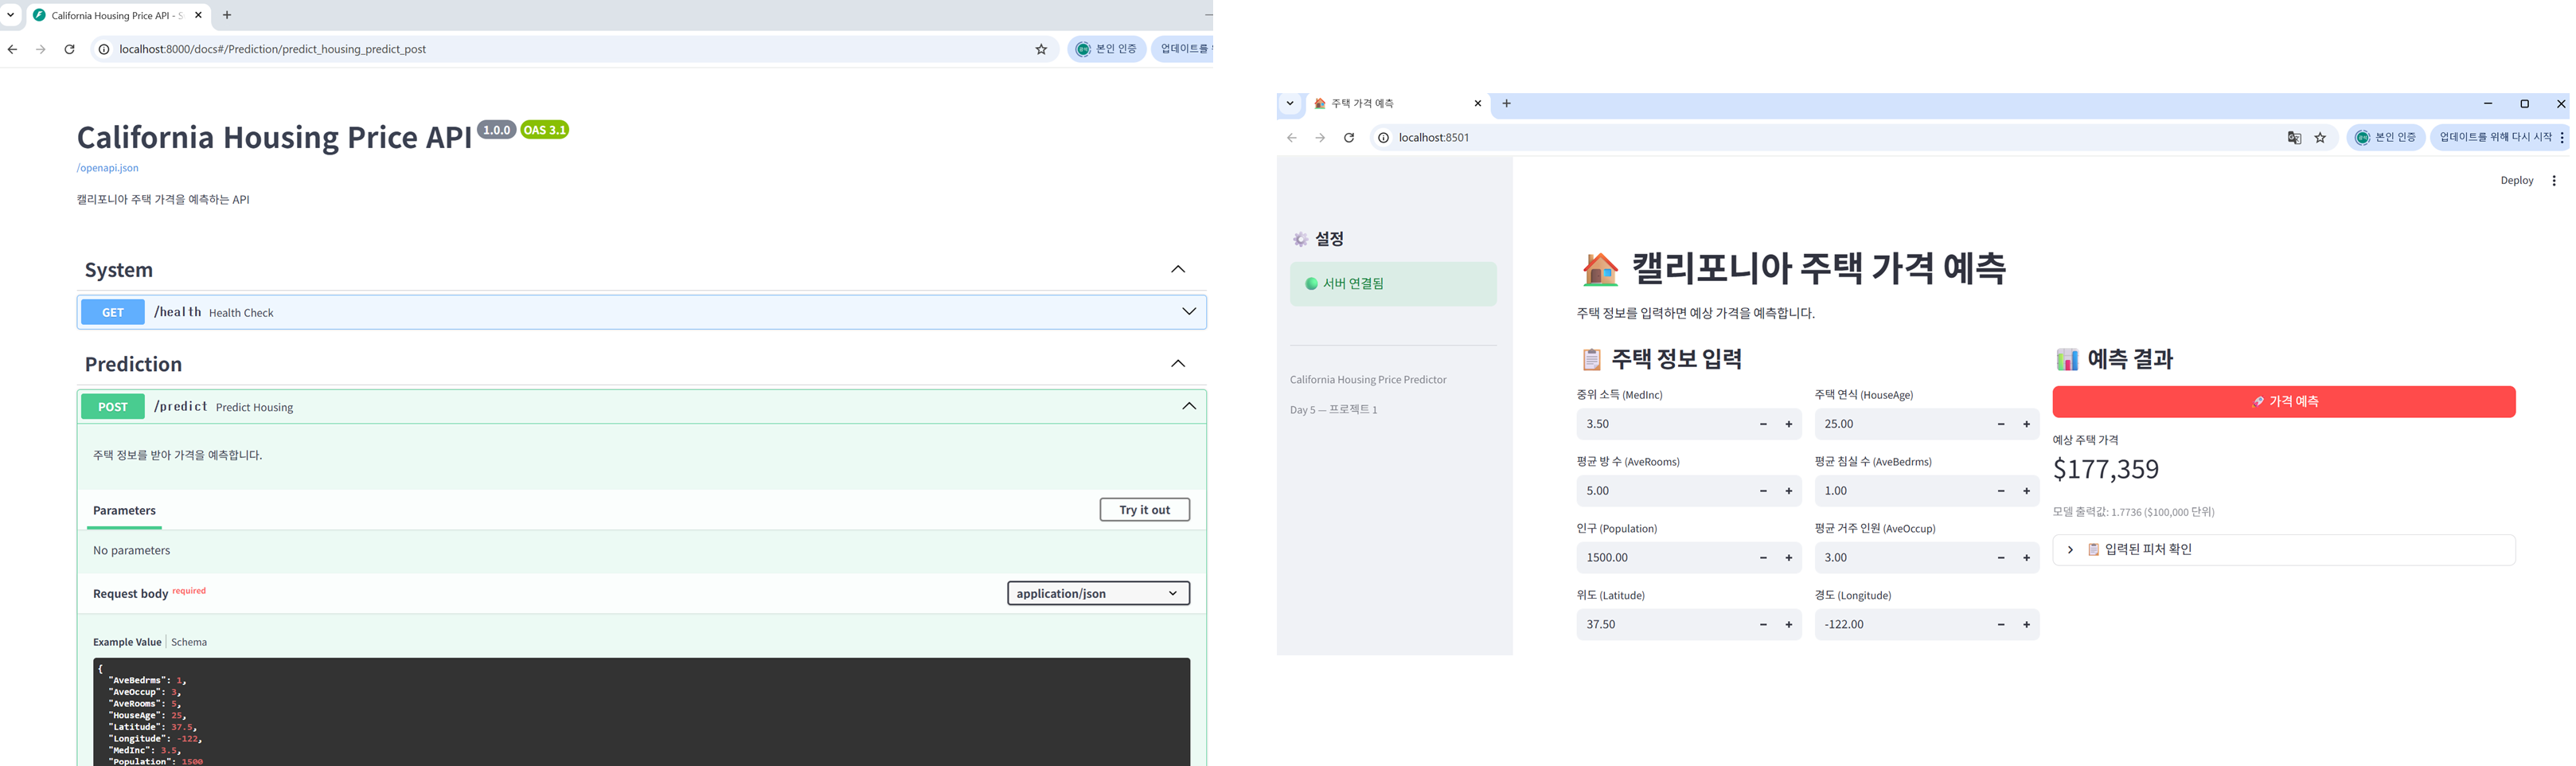

#### 테스트 시나리오

```
브라우저(http://localhost:8501) 또는 Colab iframe에서 바로 조작합니다.

[테스트 1] 기본 흐름
  1. 사이드바 서버 상태 🟢 확인
  2. 기본값 그대로 "🚀 가격 예측" 클릭
  3. 예상 가격이 표시되는지 확인

[테스트 2] 값 변경
  1. 중위 소득을 8.0으로 올리기 → 가격 예측 → 가격 상승 확인
  2. 중위 소득을 1.0으로 내리기 → 가격 예측 → 가격 하락 확인

[테스트 3] 에러 상황
  1. 백엔드 서버를 종료 — 노트북 새 셀에서 stop_server(8000) 실행
  2. 사이드바 상태가 🔴으로 변하는지 확인
  3. 다시 살리려면 serve_in_thread("app.housing_api:app", port=8000)
```

---

### ✅ 체크포인트

1. MNIST 대시보드(Day 4)와 비교했을 때 입력 방식이 어떻게 다릅니까?
2. `st.number_input()`에서 `min_value`, `max_value`를 설정하는 이유는?
3. `request_data` 딕셔너리의 키 이름이 `HousingRequest` 스키마의 필드 이름과 정확히 일치해야 하는 이유는?

---

> **다음 섹션에서는** 전체 서비스를 통합 테스트합니다.

## 5. 통합 테스트 및 디버깅

---

> **학습 목표**
> - 전체 서비스(모델 → API → UI)가 정상 동작하는지 체계적으로 테스트합니다.
> - 다양한 입력으로 모델의 동작을 확인합니다.
> - 에러 상황에서 서버가 안정적으로 동작하는지 검증합니다.

---

### 5.1 API 레벨 통합 테스트

In [27]:
# ⚠️ FastAPI 서버가 실행 중이어야 합니다.

import requests
import json
import time

API_BASE = "http://localhost:8000"

test_results = {}   # 각 테스트가 실제 결과를 여기에 기록합니다 — 마지막 종합에서 사용

print("=" * 60)
print("  통합 테스트")
print("=" * 60)


  통합 테스트


#### 테스트 1: 정상 요청

In [28]:
# 다양한 입력으로 모델 동작 확인
test_cases = [
    {"name": "저소득 지역", "MedInc": 1.5, "HouseAge": 40, "AveRooms": 4.0, "AveBedrms": 1.0,
     "Population": 2000, "AveOccup": 3.5, "Latitude": 34.0, "Longitude": -118.0},
    {"name": "고소득 지역", "MedInc": 10.0, "HouseAge": 10, "AveRooms": 8.0, "AveBedrms": 2.0,
     "Population": 500, "AveOccup": 2.0, "Latitude": 37.8, "Longitude": -122.4},
    {"name": "평균적 주택", "MedInc": 3.5, "HouseAge": 25, "AveRooms": 5.0, "AveBedrms": 1.0,
     "Population": 1500, "AveOccup": 3.0, "Latitude": 37.5, "Longitude": -122.0},
]

print("\n[테스트 1] 정상 요청 — 다양한 입력")
print(f"{'케이스':<15} {'예측 가격':>12}")
print("-" * 30)

statuses = []
for case in test_cases:
    name = case.pop("name")
    # *your code* — POST 요청
    # FastAPI의 @app.post("/predict")로 JSON 본문을 보냅니다.
    # json=case 가 Content-Type: application/json 과 HousingRequest 필드들을 채웁니다.
    resp = requests.post(f"{API_BASE}/predict", json=case)
    statuses.append(resp.status_code)
    if resp.status_code == 200:
        print(f"{name:<15} ${resp.json()['predicted_price_usd']:>10,}")
    else:
        print(f"{name:<15} ❌ HTTP {resp.status_code}")
    case["name"] = name  # 복원

test_results["정상 요청"] = all(s == 200 for s in statuses)   # 세 케이스 모두 200이어야 통과


[테스트 1] 정상 요청 — 다양한 입력
케이스                    예측 가격
------------------------------
저소득 지역          $   106,548
고소득 지역          $   487,085
평균적 주택          $   180,799


#### 테스트 2: 에러 상황

In [29]:
print("\n[테스트 2] 에러 상황")
error_statuses = []

# 필수 필드 누락
resp = requests.post(f"{API_BASE}/predict", json={"MedInc": 3.5})
error_statuses.append(resp.status_code)
print(f"  필드 누락      → HTTP {resp.status_code}")

# 범위 초과 (위도)
bad_request = {
    "MedInc": 3.5, "HouseAge": 25, "AveRooms": 5, "AveBedrms": 1,
    "Population": 1500, "AveOccup": 3, "Latitude": 50.0, "Longitude": -122.0,  # 위도 초과
}
resp = requests.post(f"{API_BASE}/predict", json=bad_request)
error_statuses.append(resp.status_code)
print(f"  위도 범위 초과  → HTTP {resp.status_code}")

# 음수 값
bad_request2 = {
    "MedInc": -1.0, "HouseAge": 25, "AveRooms": 5, "AveBedrms": 1,
    "Population": 1500, "AveOccup": 3, "Latitude": 37.5, "Longitude": -122.0,
}
resp = requests.post(f"{API_BASE}/predict", json=bad_request2)
error_statuses.append(resp.status_code)
print(f"  소득 음수      → HTTP {resp.status_code}")

# JSON이 아닌 요청
resp = requests.post(f"{API_BASE}/predict", data="not json")
error_statuses.append(resp.status_code)
print(f"  잘못된 포맷    → HTTP {resp.status_code}")

# 모두 4xx(클라이언트 잘못)로 거부되어야 통과 — 200(통과시킴)이나 500(서버 죽음)이면 실패
test_results["에러 처리"] = all(400 <= s < 500 for s in error_statuses)



[테스트 2] 에러 상황


POST /predict → 422 (0.057s)


  필드 누락      → HTTP 422

POST /predict → 422 (0.002s)
POST /predict → 422 (0.003s)
POST /predict → 422 (0.003s)



  위도 범위 초과  → HTTP 422
  소득 음수      → HTTP 422
  잘못된 포맷    → HTTP 422


#### 테스트 3: 동시 요청

In [30]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_predict(i):
    case = test_cases[i % len(test_cases)].copy()
    case.pop("name", None)
    start = time.time()
    resp = requests.post(f"{API_BASE}/predict", json=case, timeout=30)
    return {"id": i+1, "elapsed": round(time.time() - start, 3), "status": resp.status_code}

print("\n[테스트 3] 동시 요청 (8개)")
start = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = [ex.submit(send_predict, i) for i in range(8)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 2)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")

test_results["동시 처리"] = all(r["status"] == 200 for r in results)   # 8건 모두 200이어야 통과



[테스트 3] 동시 요청 (8개)
  요청 #1: 0.042초 (HTTP 200)
  요청 #2: 0.036초 (HTTP 200)
  요청 #3: 0.049초 (HTTP 200)
  요청 #4: 0.04초 (HTTP 200)
  요청 #5: 0.041초 (HTTP 200)
  요청 #6: 0.041초 (HTTP 200)
  요청 #7: 0.034초 (HTTP 200)
  요청 #8: 0.033초 (HTTP 200)
  전체: 0.06초


#### 테스트 4: 헬스체크

In [31]:
print("\n[테스트 4] 헬스체크")
resp = requests.get(f"{API_BASE}/health")
print(f"  상태: {resp.json()}")

test_results["헬스체크"] = resp.status_code == 200 and resp.json().get("status") == "healthy"



[테스트 4] 헬스체크
  상태: {'status': 'healthy', 'model': 'California Housing'}


---

### 5.2 테스트 결과 종합

In [32]:
print("\n" + "=" * 60)
print("  테스트 결과 종합")
print("=" * 60)

# 위 테스트 셀들이 test_results에 기록한 '실제 결과'로 판정합니다.
DESCRIPTIONS = {
    "정상 요청": "다양한 입력에서 200과 예측 가격 반환",
    "에러 처리": "잘못된 입력을 4xx로 거부, 서버 안 죽음",
    "동시 처리": "8개 동시 요청 모두 200",
    "헬스체크": "서버 상태 healthy",
}

for key, desc in DESCRIPTIONS.items():
    if key not in test_results:
        print(f"  ⚠️ {key}: 아직 실행되지 않음 — 위 테스트 셀을 먼저 실행하세요")
    elif test_results[key]:
        print(f"  ✅ {key}: {desc}")
    else:
        print(f"  ❌ {key}: 실패 — 위 테스트 셀의 출력을 확인하세요")

if all(test_results.get(k) for k in DESCRIPTIONS):
    print("\n🎉 4가지 테스트를 모두 통과했습니다. 회고를 작성하고 제출하세요!")
else:
    print("\n⚠️ 통과하지 못한 테스트가 있습니다. 서버 상태와 위 셀들의 출력을 확인하세요.")



  테스트 결과 종합
  ✅ 정상 요청: 다양한 입력에서 200과 예측 가격 반환
  ✅ 에러 처리: 잘못된 입력을 4xx로 거부, 서버 안 죽음
  ✅ 동시 처리: 8개 동시 요청 모두 200
  ✅ 헬스체크: 서버 상태 healthy

🎉 4가지 테스트를 모두 통과했습니다. 회고를 작성하고 제출하세요!


---

## 6. 회고: 무엇이 어려웠고, 어떻게 개선할 수 있는가?

---

### 6.1 오늘 만든 것 정리

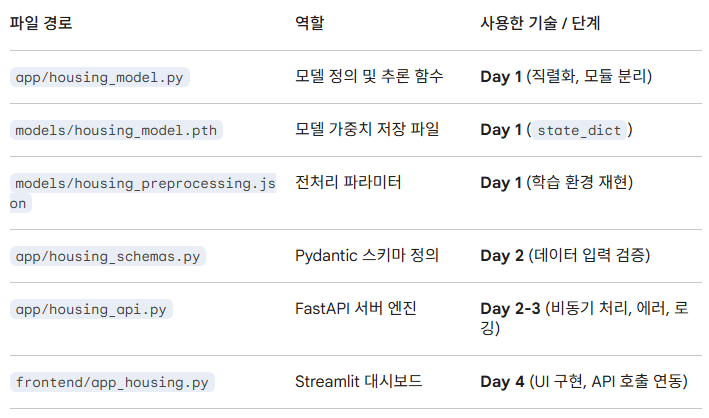



### 6.2 Day 1~4와의 연결



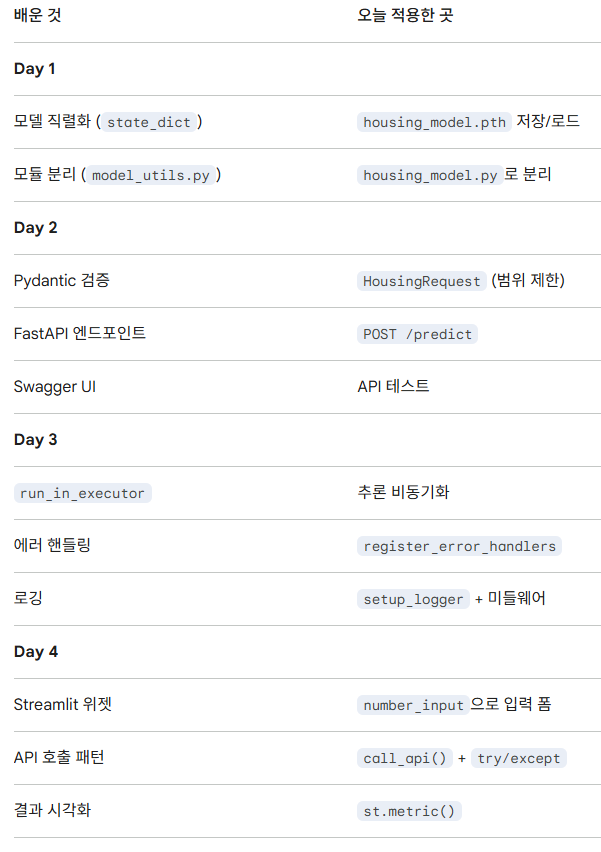

### 6.3 개선할 수 있는 점


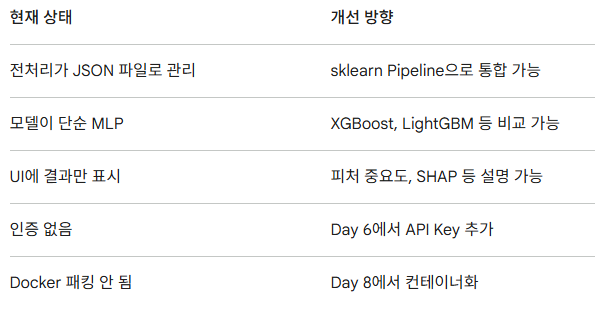



> 이 개선점들은 이 과정의 나머지 Day에서 하나씩 다루거나,
> 이후 MLOps 과정에서 심화합니다.

---

### ✅ Day 5 최종 체크포인트

```
Q1. 전처리 파라미터(mean, std)를 모델과 함께 저장해야 하는 이유는?
Q2. HousingRequest에서 Latitude에 ge=32, le=42를 넣은 이유는?
Q3. Streamlit의 입력값 이름이 Pydantic 스키마의 필드 이름과 일치해야 하는 이유는?
Q4. 이 프로젝트에서 run_in_executor를 제거하면 어떤 문제가 생길 수 있습니까?
Q5. MNIST 프로젝트(Day 1~4)와 오늘 프로젝트의 가장 큰 차이는 무엇입니까?
```

**Q1.** 학습 때 쓴 정규화와 **같은 기준**으로 추론 입력을 맞춰야 합니다. `mean`/`std`가 없으면 배포 환경에서 스케일이 달라져 예측이 틀어집니다. 가중치만으로는 전처리를 재현할 수 없습니다.

**Q2.** 캘리포니아 위도 범위입니다. 이 밖 값은 학습 분포 밖이라 잘못된 예측이 나기 쉽습니다. Pydantic이 요청 단계에서 거절해 **422**로 막습니다.

**Q3.** FastAPI는 JSON 키를 `HousingRequest` 필드에 매핑합니다. 이름이 다르면 필수 필드 누락으로 보이거나 값이 안 들어가 **422**가 납니다. UI 변수명과 API 계약이 같아야 합니다.

**Q4.** `async def` 안에서 동기 PyTorch 추론이 **이벤트 루프를 막습니다.** 동시 요청과 `/health`까지 지연되고, 로드밸런서·오케스트레이터가 서버를 죽은 것으로 볼 수 있습니다. CPU 추론은 스레드풀로 넘겨야 합니다.

**Q5.** MNIST는 **이미지 분류**(파일/픽셀 입력, 클래스 출력)이고, Day 5는 **정형 데이터 회귀**(숫자 피처 폼 입력, 가격 출력)입니다. 파이프라인(FastAPI + Streamlit)은 같고, 전처리·스키마·UI가 데이터 형태에 맞게 바뀝니다.

---

### 📌 Day 5 요약

```
오늘 한 일:
  ✅ 캘리포니아 주택 가격 데이터를 탐색하고 전처리 파이프라인을 구성했습니다.
  ✅ PyTorch 회귀 모델을 학습하고 전처리 파라미터와 함께 저장했습니다.
  ✅ FastAPI로 추론 API를 구축했습니다 (Pydantic 검증 + 비동기 처리).
  ✅ Streamlit으로 입력 폼 대시보드를 만들고 API와 연결했습니다.
  ✅ 통합 테스트로 정상/에러/동시 요청을 검증했습니다.
  ✅ Day 1~4의 모든 기술을 하나의 서비스에 통합하는 경험을 했습니다.

내일 할 일 (Day 6):
  🔜 API Key 인증을 적용하여 허용된 사용자만 호출하도록 합니다.
  🔜 이미지, 텍스트 등 비정형 데이터를 처리하는 방법을 배웁니다.
  🔜 파일 업로드와 안전장치(크기 제한, 리사이징)를 구현합니다.
```

---

> **Day 6 예고**
>
> 프로젝트 1은 누구나 접근할 수 있었습니다.
> 실서비스에서는 허용된 사용자만 API를 호출해야 합니다.
> 내일은 API Key 인증을 적용하고, 정형 데이터를 넘어
> 이미지·텍스트 같은 비정형 데이터를 다루는 법을 배웁니다.